# Notebook 3 — Latent Factor Discovery Using MOFA

**Workshop:** AI-Driven Multi-Omics Analysis  
**Use case:** Latent factor discovery across multiple molecular views  
**Method:** Multi-Omics Factor Analysis (MOFA / mofapy2)  
**Dataset:** TCGA-BRCA frozen cohort — 617 patients  
**Modalities:** RNA-seq · miRNA · DNA methylation  
**Runtime:** minutes on CPU

---

### Scientific question

> *Can a multi-omics factor model discover hidden sources of molecular variation that are shared across RNA, miRNA, and methylation simultaneously?*

### How MOFA differs from Notebook 2 (CCA)

| | CCA (Notebook 2) | MOFA (Notebook 3) |
|---|---|---|
| **Modalities** | Two (RNA ↔ miRNA) | Three (RNA + miRNA + methylation) |
| **Question** | Which combinations of two modalities are maximally correlated? | What latent factors explain variation across all modalities? |
| **Output** | Canonical variates | Latent factors with per-view variance explained |
| **Interpretability** | Linear loadings per pair | Loadings per view per factor |

MOFA treats each omics layer as a separate **"view"** and learns shared latent factors that jointly explain variation within and across all views. Unlike CCA, MOFA allows a factor to be relevant in some views but not others, reflecting the biological reality that not every regulatory signal spans all molecular layers.

> ⚠️ **PAM50 labels are not used during model fitting.** They appear only at the end as an external biological reference.

In [1]:
import time, json, warnings
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_DIR   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})

# ── Verify mofapy2 ─────────────────────────────────────────────────────────────
import mofapy2
print(f"mofapy2 version : {mofapy2.__version__}")
print(f"Project root    : {PROJECT_DIR}")

t_start = time.time()

mofapy2 version : 0.7.5
Project root    : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop


---
## Part 1 — Load the Frozen TCGA-BRCA Data

All matrices come from `data/processed/` generated in Notebook 1. Raw TCGA files are not reloaded.

In [2]:
paths = {
    "rna"    : PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",
    "mirna"  : PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv",
    "meth"   : PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv",
    "cohort" : PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
}
for k, p in paths.items():
    if not p.exists():
        raise FileNotFoundError(f"Required file missing: {p}\nRun Notebook 1 first.")

rna_df    = pd.read_csv(paths["rna"],    sep="\t", index_col=0)
mirna_df  = pd.read_csv(paths["mirna"],  sep="\t", index_col=0)
meth_df   = pd.read_csv(paths["meth"],   sep="\t", index_col=0)
cohort_df = pd.read_csv(paths["cohort"], sep="\t", index_col="sample_id")

# ── Integrity checks ──────────────────────────────────────────────────────────
assert list(rna_df.index) == list(mirna_df.index) == list(meth_df.index), \
    "Sample ordering mismatch across modalities"
assert rna_df.isnull().sum().sum() == 0
assert mirna_df.isnull().sum().sum() == 0
assert meth_df.isnull().sum().sum() == 0
assert rna_df.columns.nunique()   == rna_df.shape[1]
assert mirna_df.columns.nunique() == mirna_df.shape[1]
assert meth_df.columns.nunique()  == meth_df.shape[1]

sample_ids = rna_df.index.tolist()
print("✅ All integrity checks passed")
print(f"  RNA-seq    : {rna_df.shape}")
print(f"  miRNA      : {mirna_df.shape}")
print(f"  Methylation: {meth_df.shape}")
print(f"  Cohort     : {cohort_df.shape}")

✅ All integrity checks passed
  RNA-seq    : (617, 1000)
  miRNA      : (617, 300)
  Methylation: (617, 1000)
  Cohort     : (617, 3)


---
## Part 2 — Compact Feature Sets for MOFA

> **Workshop note:** MOFA does not require all 2,300 features for a demonstration. We select a compact subset using variance-based feature selection — the same unsupervised, label-free criterion used in Notebook 1. This step is for **computational simplicity and demonstration**, not definitive biological feature selection.

| View | Before | After | Method |
|---|---|---|---|
| RNA-seq | 1,000 genes | 100 genes | Top 100 by variance |
| miRNA | 300 miRNAs | 30 miRNAs | Top 30 by variance |
| Methylation | 1,000 CpGs | 100 CpGs | Top 100 by variance |

Total MOFA input: **617 samples × 230 features across 3 views**

In [3]:
N_RNA  = 100
N_MIR  = 30
N_METH = 100

top_rna  = rna_df.var(axis=0).nlargest(N_RNA).index
top_mir  = mirna_df.var(axis=0).nlargest(N_MIR).index
top_meth = meth_df.var(axis=0).nlargest(N_METH).index

rna_sel  = rna_df[top_rna].copy()      # (617, 100)
mir_sel  = mirna_df[top_mir].copy()    # (617, 30)
meth_sel = meth_df[top_meth].copy()    # (617, 100)

print(f"Selected features (no labels used):")
print(f"  RNA-seq    : {rna_sel.shape}")
print(f"  miRNA      : {mir_sel.shape}")
print(f"  Methylation: {meth_sel.shape}")
print(f"  Total      : {rna_sel.shape[1] + mir_sel.shape[1] + meth_sel.shape[1]} features × {rna_sel.shape[0]} samples")

Selected features (no labels used):
  RNA-seq    : (617, 100)
  miRNA      : (617, 30)
  Methylation: (617, 100)
  Total      : 230 features × 617 samples


---
## Part 3 — Define Three Molecular Views

Instead of concatenating all measurements into one large matrix, **MOFA retains the identity of each molecular modality** and learns latent factors that explain variation within and across these views.

Each view is prepared as a **features × samples** matrix (MOFA convention: rows = features, columns = samples) and standardised with `StandardScaler`. This ensures features within each view are on comparable scales. The Xena log-transformation is preserved — no additional log transform is applied.

In [4]:
def standardise_view(df):
    """Standardise samples×features → return features×samples (MOFA convention)."""
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df.values)   # samples × features
    return pd.DataFrame(scaled.T,              # features × samples
                        index=df.columns,
                        columns=df.index)

view_rna  = standardise_view(rna_sel)   # (100, 617)
view_mir  = standardise_view(mir_sel)   # (30,  617)
view_meth = standardise_view(meth_sel)  # (100, 617)

VIEW_NAMES = ["RNA-seq", "miRNA", "Methylation"]
views      = [view_rna, view_mir, view_meth]

print("MOFA views prepared (features × samples):")
for name, v in zip(VIEW_NAMES, views):
    print(f"  {name:<12}: {v.shape[0]} features × {v.shape[1]} samples")
print(f"\nAll views share the same {v.shape[1]} sample columns: "
      f"{list(view_rna.columns[:3])} …")

MOFA views prepared (features × samples):
  RNA-seq     : 100 features × 617 samples
  miRNA       : 30 features × 617 samples
  Methylation : 100 features × 617 samples

All views share the same 617 sample columns: ['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01'] …


---
## Part 4 — Train MOFA

We use **`mofapy2`** with 5 latent factors. The model is trained on all 617 samples in exploratory mode — no train/test split, since this is latent-factor discovery rather than predictive modelling.

**Key training choices:**
- `n_factors = 5` — sufficient to demonstrate the concept without over-complicating interpretation
- `convergence_mode = "fast"` — suitable for a workshop demonstration
- `seed` set for reproducibility
- PAM50 labels not used at any stage

In [5]:
from mofapy2.run.entry_point import entry_point

N_FACTORS = 5

# ── Build long-format DataFrame required by set_data_df ───────────────────────
# Required columns: sample, feature, view, group, value
# views: list of (view_name, DataFrame features×samples)
long_rows = []
for vname, view_df in zip(VIEW_NAMES, views):
    # view_df is features × samples; melt to long format
    for feat in view_df.index:
        for samp in view_df.columns:
            long_rows.append({
                "sample" : samp,
                "feature": feat,
                "view"   : vname,
                "group"  : "BRCA",
                "value"  : float(view_df.loc[feat, samp]),
            })

data_long = pd.DataFrame(long_rows)
print(f"Long-format data: {data_long.shape}  "
      f"(expected {sum(v.shape[0] * v.shape[1] for v in views):,} rows)")
print(f"  views  : {sorted(data_long['view'].unique())}")
print(f"  groups : {sorted(data_long['group'].unique())}")
print(f"  samples: {data_long['sample'].nunique()}")

t_mofa = time.time()

ent = entry_point()
ent.set_data_options(scale_views=False)   # already standardised
ent.set_data_df(data_long, likelihoods=["gaussian", "gaussian", "gaussian"])
ent.set_model_options(factors=N_FACTORS)
ent.set_train_options(
    convergence_mode="fast",
    seed=SEED,
    verbose=False,
    gpu_mode=False,
)
ent.build()
ent.run()

mofa_time = time.time() - t_mofa
print(f"\nMOFA trained in {mofa_time:.1f} seconds")

Long-format data: (141910, 5)  (expected 141,910 rows)
  views  : ['Methylation', 'RNA-seq', 'miRNA']
  groups : ['BRCA']
  samples: 617

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Loaded group='BRCA' view='Methylation' with N=617 samples and D=100 features...
Loaded group='BRCA' view='RNA-seq' with N=617 samples and D=100 features...
Loaded group='BRCA' view='miRNA' with N=617 samples and D=30 features...


Model options:
- A

---
## Part 5 — Extract Model Outputs

Extract factor scores (Z), feature loadings (W), and variance explained (R²) from the trained model.

In [6]:
model = ent.model
factor_cols = [f"Factor{i+1}" for i in range(N_FACTORS)]

# ── View ordering (set during training) ───────────────────────────────────────
views_order = ent.data_opts.get("views_names",
              ent.data_opts.get("view_names", VIEW_NAMES))

# ── Factor scores Z: ndarray (617, 5) ─────────────────────────────────────────
Z_arr = model.nodes["Z"].getExpectation()
Z_df  = pd.DataFrame(Z_arr, index=sample_ids, columns=factor_cols)
Z_df.index.name = "sample_id"
print(f"Factor scores (Z): {Z_df.shape}")

# ── Feature loadings W: list[view] of ndarray(features, K) ───────────────────
W_expect = model.nodes["W"].getExpectation()
W_dict   = {}
for i, vname in enumerate(views_order):
    feat_names = views[VIEW_NAMES.index(vname)].index.tolist()
    W_dict[vname] = pd.DataFrame(W_expect[i], index=feat_names, columns=factor_cols)

print("Loadings shapes:", {k: v.shape for k, v in W_dict.items()})

# ── Variance explained: list[1] containing ndarray(n_views, K) ───────────────
r2_matrix = model.calculate_variance_explained()[0]   # shape: (3, 5)
r2_rows   = []
for v_idx, vname in enumerate(views_order):
    for k_idx, factor in enumerate(factor_cols):
        r2_rows.append({"view": vname, "factor": factor,
                         "variance_explained": float(r2_matrix[v_idx, k_idx])})

r2_df = pd.DataFrame(r2_rows)

print("\nVariance explained (R²) per factor per view:")
for vname in views_order:
    vals = r2_df[r2_df["view"] == vname]["variance_explained"].tolist()
    print(f"  {vname:<12}: {[round(x, 4) for x in vals]}")

Factor scores (Z): (617, 5)
Loadings shapes: {'Methylation': (100, 5), 'RNA-seq': (100, 5), 'miRNA': (30, 5)}

Variance explained (R²) per factor per view:
  Methylation : [0.1861, 0.036, 0.0945, 0.0151, 0.0753]
  RNA-seq     : [0.2069, 0.1093, 0.0278, 0.0487, 0.0054]
  miRNA       : [0.1138, 0.063, 0.022, 0.0236, 0.01]


In [7]:
# ── Save existing MOFA outputs only: no retraining or recalculation ───────────
from pathlib import Path

MOFA_OUTPUT_DIR = Path("../data/processed")
MOFA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

factor_names = list(factor_cols)
existing_scores = Z_df if "Z_df" in globals() else pd.DataFrame(
    Z if "Z" in globals() else Z_arr,
    index=sample_ids,
    columns=factor_names,
)
existing_scores.index.name = "sample_id"
existing_scores.to_csv(
    MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_factor_scores.tsv",
    sep="\t",
)

existing_loadings = W_dict if "W_dict" in globals() else loadings
loading_paths = {
    "Methylation": "TCGA_BRCA_MOFA_loadings_methylation.tsv",
    "RNA-seq": "TCGA_BRCA_MOFA_loadings_rna.tsv",
    "miRNA": "TCGA_BRCA_MOFA_loadings_mirna.tsv",
}
for view_name, filename in loading_paths.items():
    existing_loadings[view_name].to_csv(
        MOFA_OUTPUT_DIR / filename,
        sep="\t",
    )

# Preserve the existing variance-explained values in view × factor format.
existing_variance = r2_df.copy()
if {"view", "factor", "variance_explained"}.issubset(existing_variance.columns):
    existing_variance = existing_variance.pivot(
        index="view",
        columns="factor",
        values="variance_explained",
    )
existing_variance = existing_variance.reindex(index=["Methylation", "RNA-seq", "miRNA"])
existing_variance.index.name = "view"
existing_variance.to_csv(
    MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_variance_explained.tsv",
    sep="\t",
)

print("Saved existing MOFA results without retraining or recalculation:")
print(f"  Factor scores: {existing_scores.shape}")
for view_name in loading_paths:
    print(f"  {view_name} loadings: {existing_loadings[view_name].shape}")
print(f"  Variance explained: {existing_variance.shape}")

Saved existing MOFA results without retraining or recalculation:
  Factor scores: (617, 5)
  Methylation loadings: (100, 5)
  RNA-seq loadings: (100, 5)
  miRNA loadings: (30, 5)
  Variance explained: (3, 5)


In [8]:
# ── Save existing MOFA results (no retraining or recalculation) ───────────────
from pathlib import Path
import pandas as pd

MOFA_OUTPUT_DIR = Path("../data/processed")
MOFA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Factor scores: use the existing DataFrame if available; otherwise build it from Z.
if "Z_df" in globals():
    factor_scores = Z_df.copy()
elif "Z" in globals():
    factor_scores = pd.DataFrame(
        Z, index=sample_ids,
        columns=[f"Factor{i + 1}" for i in range(Z.shape[1])],
    )
else:
    factor_scores = pd.DataFrame(
        Z_arr, index=sample_ids,
        columns=[f"Factor{i + 1}" for i in range(Z_arr.shape[1])],
    )
factor_scores.index.name = "sample_id"

factor_scores_path = MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_factor_scores.tsv"
factor_scores.to_csv(factor_scores_path, sep="\t")

# Feature loadings: save one feature × factor table per molecular view.
loading_tables = W_dict if "W_dict" in globals() else loadings
loading_paths = {
    "Methylation": MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_loadings_methylation.tsv",
    "RNA-seq": MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_loadings_rna.tsv",
    "miRNA": MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_loadings_mirna.tsv",
}
for view_name, output_path in loading_paths.items():
    loading_tables[view_name].to_csv(output_path, sep="\t")

# Variance explained: preserve the existing result without recalculating it.
variance_table = r2_df.copy()
if {"view", "factor", "variance_explained"}.issubset(variance_table.columns):
    variance_table = variance_table.pivot(
        index="view", columns="factor", values="variance_explained"
    ).reindex(index=["Methylation", "RNA-seq", "miRNA"])
variance_table.index.name = "view"
variance_path = MOFA_OUTPUT_DIR / "TCGA_BRCA_MOFA_variance_explained.tsv"
variance_table.to_csv(variance_path, sep="\t")

print("MOFA results saved without retraining or recalculation:")
print(f"  Factor scores       : {factor_scores.shape} -> {factor_scores_path}")
for view_name, output_path in loading_paths.items():
    print(f"  {view_name:<18}: {loading_tables[view_name].shape} -> {output_path}")
print(f"  Variance explained  : {variance_table.shape} -> {variance_path}")

MOFA results saved without retraining or recalculation:
  Factor scores       : (617, 5) -> ..\data\processed\TCGA_BRCA_MOFA_factor_scores.tsv
  Methylation       : (100, 5) -> ..\data\processed\TCGA_BRCA_MOFA_loadings_methylation.tsv
  RNA-seq           : (100, 5) -> ..\data\processed\TCGA_BRCA_MOFA_loadings_rna.tsv
  miRNA             : (30, 5) -> ..\data\processed\TCGA_BRCA_MOFA_loadings_mirna.tsv
  Variance explained  : (3, 5) -> ..\data\processed\TCGA_BRCA_MOFA_variance_explained.tsv


---
## Part 6 — Variance Explained

Each MOFA factor captures a fraction of the total variance in each view. The **variance explained** tells us how important each factor is and which molecular modalities it is most strongly associated with.

Total variance explained per factor (sum across 3 views):
  Factor1: 0.5068
  Factor2: 0.2083
  Factor3: 0.1443
  Factor4: 0.0874
  Factor5: 0.0907


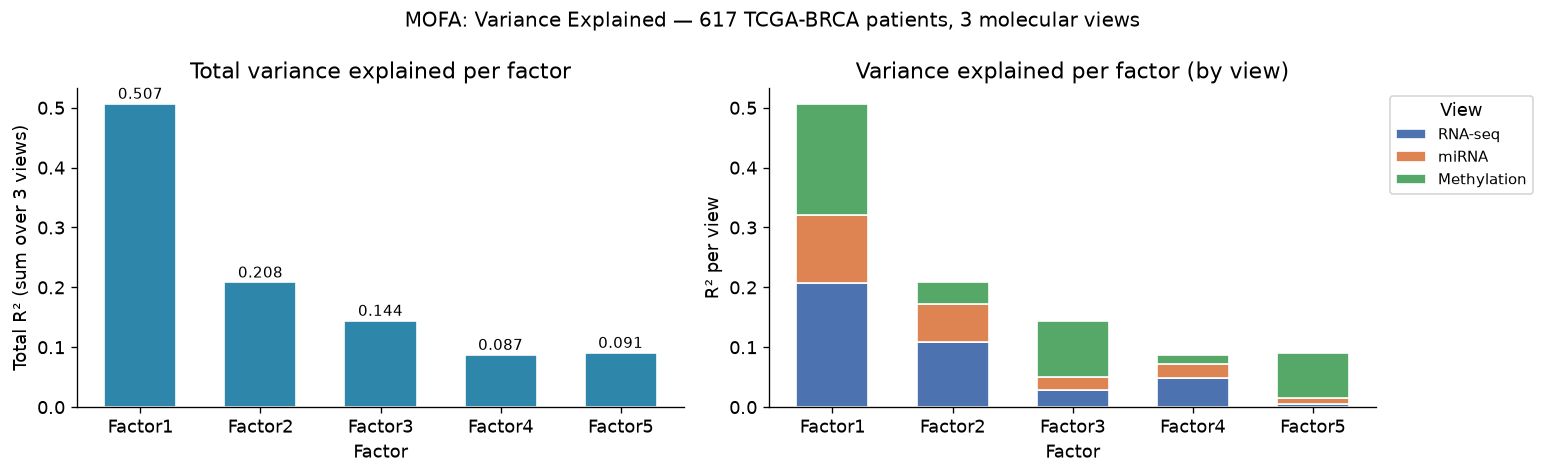

In [9]:
VIEW_COLORS = {"RNA-seq": "#4C72B0", "miRNA": "#DD8452", "Methylation": "#55A868"}

# ── Total R² per factor (sum across views) ────────────────────────────────────
total_r2 = r2_df.groupby("factor")["variance_explained"].sum().reindex(factor_cols)
print("Total variance explained per factor (sum across 3 views):")
for f, v in total_r2.items():
    print(f"  {f}: {v:.4f}")

# ── Plot 1: Total variance per factor ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(factor_cols, total_r2.values, color="#2E86AB", edgecolor="white", width=0.6)
for i, v in enumerate(total_r2.values):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
axes[0].set_xlabel("Factor"); axes[0].set_ylabel("Total R² (sum over 3 views)")
axes[0].set_title("Total variance explained per factor")

# ── Plot 2: Stacked view-wise R² ──────────────────────────────────────────────
r2_wide = r2_df.pivot(index="factor", columns="view", values="variance_explained")
r2_wide = r2_wide.reindex(factor_cols)

bottom = np.zeros(N_FACTORS)
for vname in VIEW_NAMES:
    vals = r2_wide[vname].values
    axes[1].bar(factor_cols, vals, bottom=bottom,
                color=VIEW_COLORS[vname], label=vname, edgecolor="white", width=0.6)
    bottom += vals

axes[1].set_xlabel("Factor"); axes[1].set_ylabel("R² per view")
axes[1].set_title("Variance explained per factor (by view)")
axes[1].legend(title="View", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.suptitle("MOFA: Variance Explained — 617 TCGA-BRCA patients, 3 molecular views",
             fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_MOFA_variance_explained.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Part 7 — Latent Factor Visualisation

We plot pairs of factors to reveal the latent structure. The first plot is **unlabelled** to show the unsupervised structure discovered by MOFA. The second plot overlays PAM50 labels as an external post-hoc reference.

> ⚠️ **PAM50 was not used during model training.**

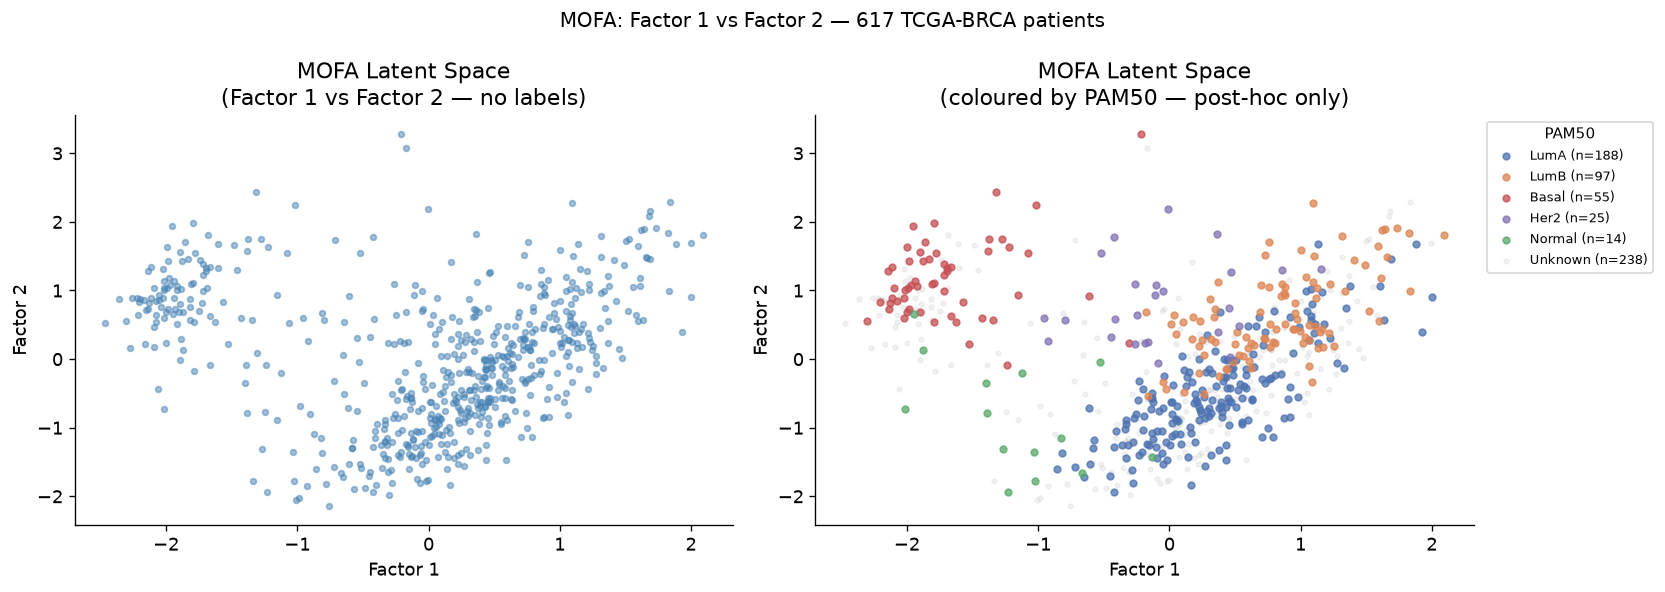

In [10]:
SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {
    "LumA": "#4C72B0", "LumB": "#DD8452", "Basal": "#C44E52",
    "Her2": "#8172B3", "Normal": "#55A868", "Unknown": "#CCCCCC",
}
pam50_labels = cohort_df["PAM50_subtype"].reindex(sample_ids).fillna("Unknown")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot A: Unlabelled ────────────────────────────────────────────────────────
axes[0].scatter(Z_df["Factor1"], Z_df["Factor2"], s=12, alpha=0.5,
                color="steelblue", rasterized=True)
axes[0].set_xlabel("Factor 1"); axes[0].set_ylabel("Factor 2")
axes[0].set_title("MOFA Latent Space\n(Factor 1 vs Factor 2 — no labels)")

# ── Plot B: PAM50-coloured ────────────────────────────────────────────────────
for st in SUBTYPE_ORDER:
    mask = pam50_labels.values == st
    if mask.sum() == 0:
        continue
    a = 0.25 if st == "Unknown" else 0.75
    s = 8    if st == "Unknown" else 16
    axes[1].scatter(Z_df["Factor1"].values[mask], Z_df["Factor2"].values[mask],
                    s=s, alpha=a, color=SUBTYPE_COLORS[st],
                    label=f"{st} (n={mask.sum()})", rasterized=True,
                    zorder=1 if st == "Unknown" else 2)
axes[1].set_xlabel("Factor 1"); axes[1].set_ylabel("Factor 2")
axes[1].set_title("MOFA Latent Space\n(coloured by PAM50 — post-hoc only)")
axes[1].legend(title="PAM50", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=8, title_fontsize=9)

plt.suptitle("MOFA: Factor 1 vs Factor 2 — 617 TCGA-BRCA patients", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_MOFA_factor_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Part 8 — Top Contributing Features per Modality

The MOFA **loadings** (W) describe how strongly each molecular feature is associated with each factor. Large absolute loadings indicate features that move strongly with the factor across patients.

> **High-loading features are candidates for biological interpretation — not proof of causal or regulatory relationships.**

Strongest factor (highest total R²): Factor1 (R²=0.5068)



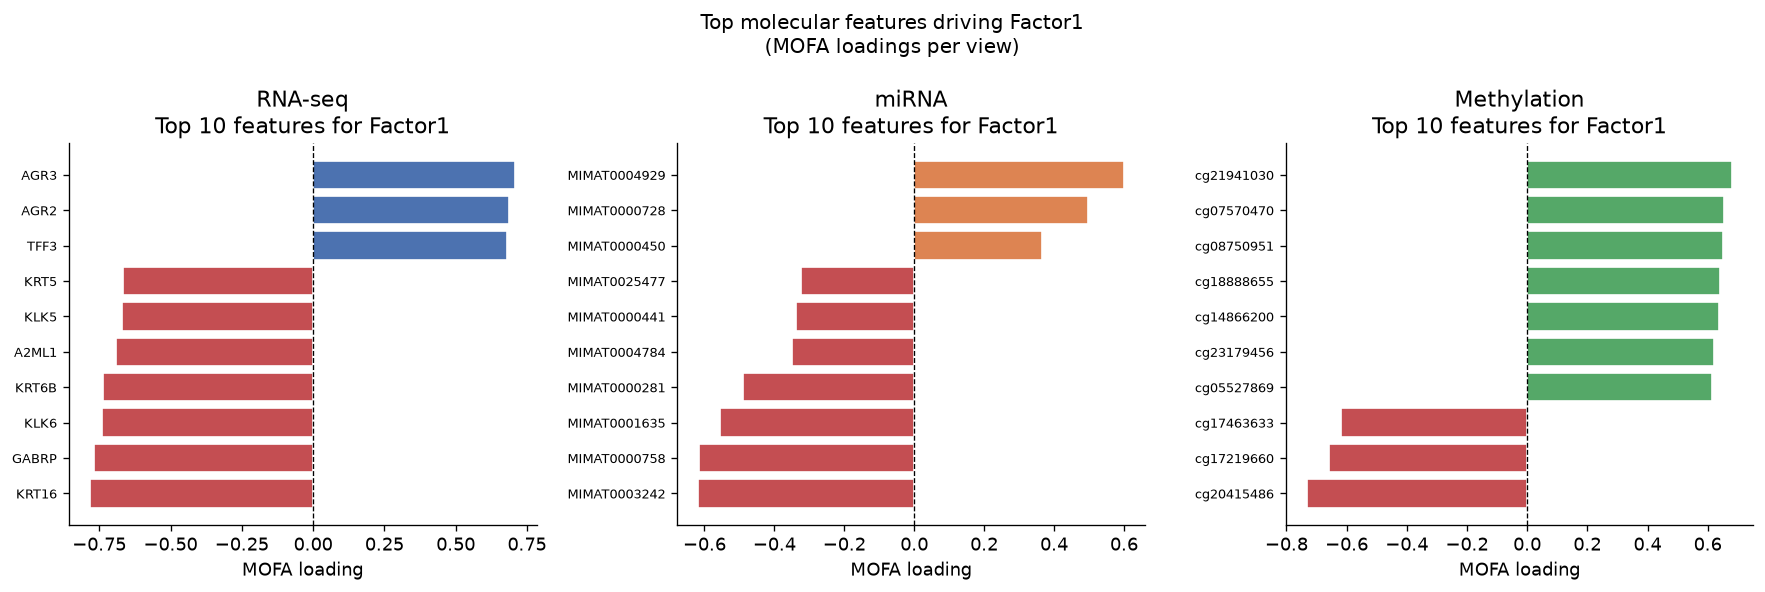

Top 10 RNA-seq features (Factor1):
       Loading
KRT16  -0.7826
GABRP  -0.7683
KLK6   -0.7408
KRT6B  -0.7384
A2ML1  -0.6920
KLK5   -0.6693
KRT5   -0.6670
TFF3    0.6815
AGR2    0.6884
AGR3    0.7088

Top 10 miRNA features (Factor1):
              Loading
MIMAT0003242  -0.6174
MIMAT0000758  -0.6169
MIMAT0001635  -0.5542
MIMAT0000281  -0.4885
MIMAT0004784  -0.3485
MIMAT0000441  -0.3376
MIMAT0025477  -0.3248
MIMAT0000450   0.3652
MIMAT0000728   0.4979
MIMAT0004929   0.5991

Top 10 Methylation features (Factor1):
            Loading
cg20415486  -0.7323
cg17219660  -0.6571
cg17463633  -0.6187
cg05527869   0.6143
cg23179456   0.6207
cg14866200   0.6388
cg18888655   0.6398
cg08750951   0.6511
cg07570470   0.6537
cg21941030   0.6813



In [11]:
N_TOP = 10
BEST_FACTOR = total_r2.idxmax()
print(f"Strongest factor (highest total R²): {BEST_FACTOR} (R²={total_r2[BEST_FACTOR]:.4f})\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
top_tables = {}

for ax, (vname, color) in zip(axes, VIEW_COLORS.items()):
    W = W_dict[vname][BEST_FACTOR]
    top_idx  = W.abs().nlargest(N_TOP).index
    top_vals = W.loc[top_idx].sort_values()
    top_tables[vname] = top_vals

    bar_colors = [color if v >= 0 else "#C44E52" for v in top_vals.values]
    ax.barh(range(len(top_vals)), top_vals.values, color=bar_colors, edgecolor="white")
    ax.set_yticks(range(len(top_vals)))
    ax.set_yticklabels(top_vals.index, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("MOFA loading")
    ax.set_title(f"{vname}\nTop {N_TOP} features for {BEST_FACTOR}")

plt.suptitle(f"Top molecular features driving {BEST_FACTOR}\n(MOFA loadings per view)",
             fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_MOFA_loadings.png",
            dpi=150, bbox_inches="tight")
plt.show()

for vname, series in top_tables.items():
    print(f"Top {N_TOP} {vname} features ({BEST_FACTOR}):")
    print(pd.DataFrame({"Loading": series.round(4)}).to_string())
    print()

---
## Part 9 — PAM50 as External Biological Reference

> PAM50 is used here **only after** the model was trained. It serves as an external biological reference to ask: *does the strongest latent factor correspond to known molecular subtype variation?*

We use a boxplot to compare Factor 1 scores across PAM50 subtypes. No classification, accuracy calculation, or model tuning is performed.

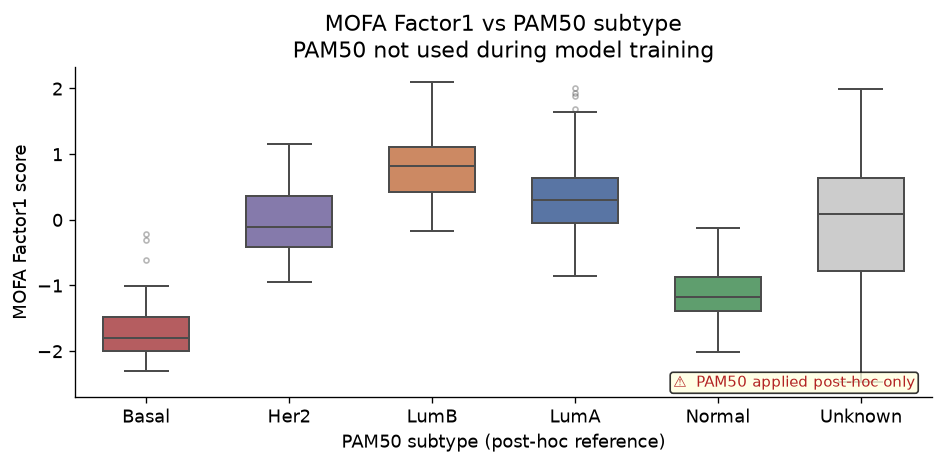

In [12]:
plot_df = pd.DataFrame({
    "Factor1"   : Z_df["Factor1"].values,
    "PAM50"     : pam50_labels.values,
    "sample_id" : sample_ids,
})

# Order subtypes meaningfully; "Unknown" last
order_present = [s for s in ["Basal", "Her2", "LumB", "LumA", "Normal", "Unknown"]
                 if s in plot_df["PAM50"].unique()]

fig, ax = plt.subplots(figsize=(8, 4))
palette = {s: SUBTYPE_COLORS[s] for s in order_present}
sns.boxplot(data=plot_df, x="PAM50", y="Factor1", order=order_present,
            palette=palette, width=0.6, linewidth=1.2, ax=ax,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax.set_xlabel("PAM50 subtype (post-hoc reference)")
ax.set_ylabel(f"MOFA {BEST_FACTOR} score")
ax.set_title(f"MOFA {BEST_FACTOR} vs PAM50 subtype\n"
             "PAM50 not used during model training")
ax.text(0.98, 0.02, "⚠️  PAM50 applied post-hoc only",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        color="firebrick", bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", alpha=0.8))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_MOFA_factor_PAM50.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [13]:
from datetime import date

# ── Factor scores ──────────────────────────────────────────────────────────────
SCORES_OUT = PROCESSED_DIR / "TCGA_BRCA_MOFA_factor_scores.tsv"
Z_df.to_csv(SCORES_OUT, sep="\t", float_format="%.6f")

# ── Variance explained ─────────────────────────────────────────────────────────
VAR_OUT = PROCESSED_DIR / "TCGA_BRCA_MOFA_variance_explained.tsv"
r2_df.to_csv(VAR_OUT, sep="\t", index=False, float_format="%.6f")

# ── Loadings ───────────────────────────────────────────────────────────────────
loading_rows = []
for vname, W in W_dict.items():
    for feat in W.index:
        for k in factor_cols:
            loading_rows.append({"modality": vname, "feature": feat,
                                  "factor": k, "loading": round(float(W.loc[feat, k]), 6)})
LOAD_OUT = PROCESSED_DIR / "TCGA_BRCA_MOFA_loadings.tsv"
pd.DataFrame(loading_rows).to_csv(LOAD_OUT, sep="\t", index=False)

# ── Metadata JSON ──────────────────────────────────────────────────────────────
total_time = time.time() - t_start
meta = {
    "created"              : str(date.today()),
    "package"              : "mofapy2",
    "package_version"      : mofapy2.__version__,
    "n_samples"            : len(sample_ids),
    "n_factors"            : N_FACTORS,
    "feature_counts"       : {"RNA-seq": N_RNA, "miRNA": N_MIR, "Methylation": N_METH},
    "feature_selection"    : "Top N most variable features per modality (variance-based, no labels)",
    "standardisation"      : "StandardScaler per view (fit on all 617 samples, exploratory mode)",
    "convergence_mode"     : "fast",
    "seed"                 : SEED,
    "no_train_test_split"  : True,
    "pam50_in_training"    : False,
    "strongest_factor"     : BEST_FACTOR,
    "total_r2_per_factor"  : {f: round(v, 6) for f, v in total_r2.items()},
    "training_time_seconds": round(mofa_time, 1),
    "total_runtime_seconds": round(total_time, 1),
}
META_OUT = PROCESSED_DIR / "TCGA_BRCA_MOFA_metadata.json"
with open(META_OUT, "w") as fh:
    json.dump(meta, fh, indent=2)

for p in [SCORES_OUT, VAR_OUT, LOAD_OUT, META_OUT]:
    print(f"✅ {p.name:<50}  {p.stat().st_size/1e3:>7.1f} KB")
print(f"\nTotal runtime: {total_time:.1f} seconds")

✅ TCGA_BRCA_MOFA_factor_scores.tsv                       39.7 KB
✅ TCGA_BRCA_MOFA_variance_explained.tsv                   0.4 KB
✅ TCGA_BRCA_MOFA_loadings.tsv                            42.6 KB
✅ TCGA_BRCA_MOFA_metadata.json                            0.8 KB

Total runtime: 20.0 seconds


---
## Why Latent Factor Models Are Useful for Multi-Omics

1. **Multi-omics datasets are high-dimensional but sample-sparse.** With thousands of molecular features and hundreds of patients, most individual feature–feature correlations are unreliable. Latent factors identify the dominant axes of variation rather than individual pairwise relationships.

2. **Many molecular measurements reflect shared underlying processes.** Genes, miRNAs, and CpGs that are all influenced by the same biological program (e.g., a master transcription factor or a tumour subtype) will tend to co-vary across patients. Latent factors capture these coherent patterns.

3. **MOFA preserves the distinction between molecular views.** Rather than concatenating all features, MOFA retains the identity of each modality and learns which modalities contribute to each factor. This directly answers: *"Is this biological signal present in RNA alone, or also in miRNA and methylation?"*

4. **Factor loadings are interpretable.** Because the model is linear (in its factor structure), each factor is explained by a ranked list of features per view — a direct bridge to biological hypothesis generation.

5. **MOFA provides a bridge between statistical dimensionality reduction and modern AI representation learning.** The latent factors are analogous to the latent dimensions of a VAE (Notebook 1), but derived through a probabilistic graphical model rather than a neural network.

---

**CCA (Notebook 2) vs MOFA (Notebook 3):**

| | CCA | MOFA |
|---|---|---|
| Question | Which combinations of two modalities are maximally correlated? | What latent factors explain variation across multiple modalities? |
| Modalities | Two | Three or more |
| Factor relevance | All features used in every component | Factors can be view-specific |
| Probabilistic | No | Yes (Bayesian) |

> **Statistical methods provide the mathematical foundation for identifying structure in high-dimensional biological data. AI models can subsequently build on these representations to learn more complex nonlinear patterns.**

---
## Interpretation and Limitations

- **Factors are data-driven and do not automatically correspond to known biological pathways.** The factor structure reflects patterns in the data; biological meaning must be established through external evidence such as pathway enrichment, literature validation, or experimental follow-up.

- **Variance explained indicates how much variation the factor captures, not biological importance.** A factor explaining 15% of RNA variance may reflect strong technical batch effects rather than meaningful biology; a factor explaining 3% may capture a clinically critical signal.

- **Feature loadings provide candidates for interpretation, not causal relationships.** High-loading genes or miRNAs are statistically associated with the factor — they are not proven regulators or drivers.

- **The compact feature set is used for workshop demonstration and is not a definitive biological feature-selection pipeline.** Variance-based selection on 100/30/100 features was chosen for speed and clarity. A publication-grade analysis would use the full feature set and validate in independent cohorts.

- **PAM50 is used only for post-hoc interpretation.** It was not available to the MOFA model during training. Alignment with PAM50 is evidence of biological relevance, not proof that the factors are equivalent to molecular subtypes.

- **The model is exploratory and should ideally be validated in an independent cohort for biological conclusions.** All variance explained and factor structures reported here are from the same 617-patient cohort used for training.

---
## Notebook 3 — Take-home Message

```
TCGA-BRCA (617 patients)
    ↓
RNA-seq  +  miRNA  +  Methylation   ← three molecular views
    ↓
Compact feature selection (100 + 30 + 100 = 230 features)
    ↓
Per-view standardisation
    ↓
MOFA (Multi-Omics Factor Analysis)
    ↓
5 latent factors
    ↓
Variance explained per factor per view
    ↓
Feature loadings → molecular feature candidates
    ↓
Post-hoc PAM50 comparison
```

- **MOFA discovers hidden molecular factors** by jointly modelling variation across RNA, miRNA, and methylation without using any clinical labels.

- **Variance explained shows which factors capture the most molecular signal** and which molecular views contribute to each factor — answering the question of whether a factor is view-specific or truly multi-omics.

- **The top-loading features per modality are interpretable candidates** for biological follow-up. They represent the molecular measurements most strongly associated with each latent factor.

- **PAM50 separation in the factor space indicates biological relevance.** When an unsupervised factor aligns with known molecular subtypes, this is evidence that the factor captures genuine tumour biology rather than technical noise.

- **MOFA demonstrates how latent factor models can compress heterogeneous multi-omics measurements into interpretable hidden factors while retaining information about which molecular modalities and features contribute to each factor.**

---
## Part 10 — Lightweight Attention-Based Multi-Omics Integration

This optional extension is appended after the MOFA evaluation and leaves every MOFA cell above unchanged. It reuses the existing standardised compact representations: RNA-seq (100 features), miRNA (30 features), and methylation (100 features). Each patient therefore has three modality tokens.

A small self-attention encoder lets the three tokens interact, then attention pooling produces one integrated patient representation. The model is trained without labels to reconstruct each standardised view from that integrated representation. PAM50 is not read or used until the post-hoc visualisation below.

In [14]:
# Small, CPU-friendly attention integrator: one token per omics modality.
import torch
from torch import nn
from sklearn.decomposition import PCA

torch.manual_seed(SEED)
torch.set_num_threads(1)

D_MODEL, N_HEADS, N_LAYERS, FF_DIM = 32, 4, 1, 64
LEARNING_RATE, MAX_EPOCHS, PATIENCE, MIN_DELTA = 1e-3, 300, 30, 1e-5
ATTENTION_VIEW_NAMES = ["RNA-seq", "miRNA", "Methylation"]

class OmicsAttentionIntegrator(nn.Module):
    def __init__(self, input_dims, d_model, n_heads, ff_dim):
        super().__init__()
        self.projectors = nn.ModuleList([nn.Linear(dim, d_model) for dim in input_dims])
        self.modality_embedding = nn.Parameter(torch.zeros(1, len(input_dims), d_model))
        self.self_attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model))
        self.norm2 = nn.LayerNorm(d_model)
        self.pooling = nn.Linear(d_model, 1)
        self.decoders = nn.ModuleList([nn.Linear(d_model, dim) for dim in input_dims])

    def forward(self, views):
        tokens = torch.stack([projector(view) for projector, view in zip(self.projectors, views)], dim=1)
        tokens = tokens + self.modality_embedding
        attended, self_weights = self.self_attention(tokens, tokens, tokens, need_weights=True,
                                                      average_attn_weights=True)
        tokens = self.norm1(tokens + attended)
        tokens = self.norm2(tokens + self.feed_forward(tokens))
        pool_weights = torch.softmax(self.pooling(tokens).squeeze(-1), dim=1)
        integrated = (tokens * pool_weights.unsqueeze(-1)).sum(dim=1)
        reconstructions = [decoder(integrated) for decoder in self.decoders]
        return integrated, reconstructions, pool_weights, self_weights

print("Attention architecture:")
print(f"  Tokens: 3 modalities (RNA-seq, miRNA, Methylation)")
print(f"  Token projections: 100/30/100 -> {D_MODEL}; learned modality embeddings")
print(f"  Encoder: {N_LAYERS} self-attention layer, {N_HEADS} heads, feed-forward width {FF_DIM}")
print(f"  Pooling: learned attention over the 3 modality tokens")
print("  Training objective: reconstruct all three standardised views; PAM50 excluded")

Attention architecture:
  Tokens: 3 modalities (RNA-seq, miRNA, Methylation)
  Token projections: 100/30/100 -> 32; learned modality embeddings
  Encoder: 1 self-attention layer, 4 heads, feed-forward width 64
  Pooling: learned attention over the 3 modality tokens
  Training objective: reconstruct all three standardised views; PAM50 excluded


In [15]:
# Existing MOFA-standardised matrices become the three modality token inputs.
attention_inputs = [
    view_rna.T.loc[sample_ids].values.astype(np.float32),
    view_mir.T.loc[sample_ids].values.astype(np.float32),
    view_meth.T.loc[sample_ids].values.astype(np.float32),
]
assert [arr.shape for arr in attention_inputs] == [(617, 100), (617, 30), (617, 100)]
attention_tensors = [torch.tensor(arr) for arr in attention_inputs]

indices = np.random.default_rng(SEED).permutation(len(sample_ids))
split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]
model_attention = OmicsAttentionIntegrator([a.shape[1] for a in attention_inputs],
                                            D_MODEL, N_HEADS, FF_DIM)
optimizer_attention = torch.optim.Adam(model_attention.parameters(), lr=LEARNING_RATE)

best_val_loss, stale, best_state = np.inf, 0, None
train_losses, val_losses = [], []
t_attention = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    model_attention.train(); optimizer_attention.zero_grad()
    _, recon, _, _ = model_attention([x[train_idx] for x in attention_tensors])
    train_loss = sum((pred - target[train_idx]).square().mean() for pred, target in zip(recon, attention_tensors)) / 3
    train_loss.backward(); optimizer_attention.step()

    model_attention.eval()
    with torch.no_grad():
        _, val_recon, _, _ = model_attention([x[val_idx] for x in attention_tensors])
        val_loss = sum((pred - target[val_idx]).square().mean() for pred, target in zip(val_recon, attention_tensors)) / 3
    train_losses.append(float(train_loss)); val_losses.append(float(val_loss))

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch, stale = float(val_loss), epoch, 0
        best_state = {k: v.detach().clone() for k, v in model_attention.state_dict().items()}
    else:
        stale += 1
        if stale >= PATIENCE: break

attention_time = time.time() - t_attention
model_attention.load_state_dict(best_state); model_attention.eval()
with torch.no_grad():
    attention_latent, _, pooling_weights, self_attention_weights = model_attention(attention_tensors)
attention_latent = attention_latent.numpy()
pooling_weights = pooling_weights.numpy()
self_attention_weights = self_attention_weights.numpy()

mean_pooling = pooling_weights.mean(axis=0)
mean_self_attention = self_attention_weights.mean(axis=0)
print(f"Early stopping: epoch {best_epoch}/{epoch}; training time: {attention_time:.2f} s")
print(f"Best validation reconstruction MSE: {best_val_loss:.5f}")
print("Mean attention-pooling weights:")
for name, weight in zip(ATTENTION_VIEW_NAMES, mean_pooling):
    print(f"  {name:<12}: {weight:.3f}")

Early stopping: epoch 300/300; training time: 6.86 s
Best validation reconstruction MSE: 0.41944
Mean attention-pooling weights:
  RNA-seq     : 0.274
  miRNA       : 0.521
  Methylation : 0.205


### Attention contribution pattern

The learned pooling weights quantify each modality token's average contribution to the integrated representation. The self-attention matrix shows how strongly each receiving modality token attends to RNA-seq, miRNA, and methylation tokens. These are model-derived importance summaries, not causal claims.

,modality,mean_pooling_weight
0,RNA-seq,0.274
1,miRNA,0.521
2,Methylation,0.205


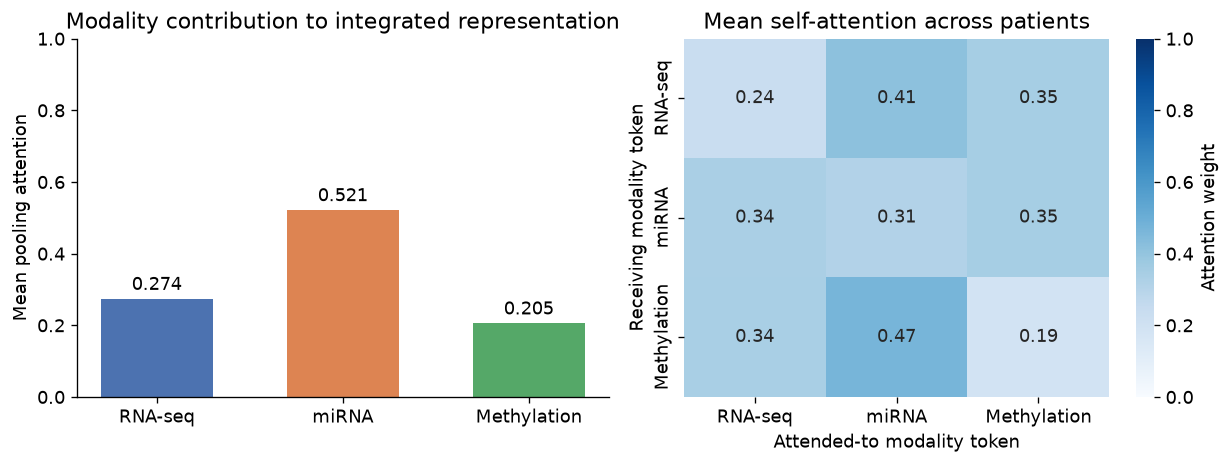

In [16]:
FIGURES_DIR = PROCESSED_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

attention_summary = pd.DataFrame({"modality": ATTENTION_VIEW_NAMES, "mean_pooling_weight": mean_pooling})
display(attention_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].bar(attention_summary["modality"], attention_summary["mean_pooling_weight"],
            color=["#4C72B0", "#DD8452", "#55A868"], width=.6)
axes[0].set(ylim=(0, 1), ylabel="Mean pooling attention", title="Modality contribution to integrated representation")
for i, value in enumerate(mean_pooling):
    axes[0].text(i, value + .025, f"{value:.3f}", ha="center")
sns.heatmap(mean_self_attention, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=ATTENTION_VIEW_NAMES, yticklabels=ATTENTION_VIEW_NAMES, ax=axes[1],
            cbar_kws={"label": "Attention weight"})
axes[1].set(xlabel="Attended-to modality token", ylabel="Receiving modality token",
            title="Mean self-attention across patients")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "TCGA_BRCA_attention_modality_weights.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparison with MOFA and post-hoc PAM50 interpretation

The first two MOFA factors and a two-dimensional PCA view of the learned attention representation are shown side by side. PAM50 is used only to colour these already learned representations.

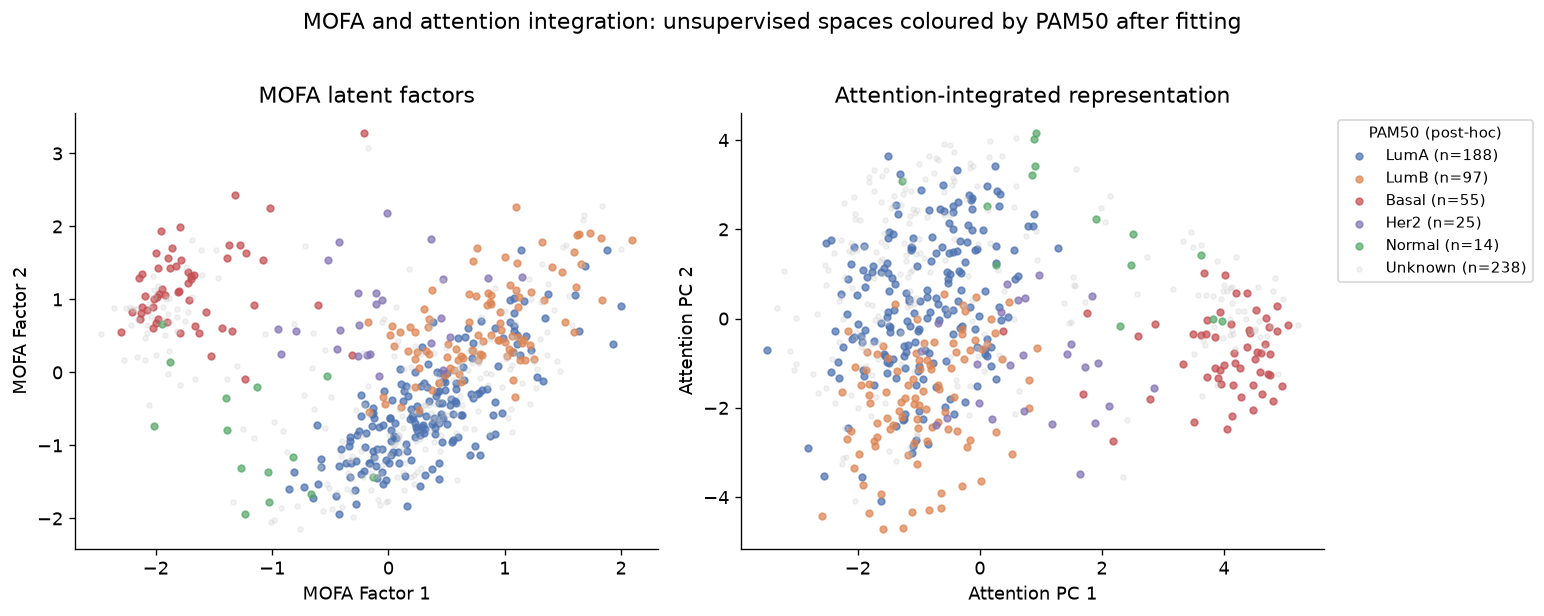

In [17]:
# PAM50 is introduced only after attention-model fitting, early stopping, and attention summaries.
attention_2d = PCA(n_components=2, random_state=SEED).fit_transform(attention_latent)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, representation, title, labels in [
    (axes[0], Z_df[["Factor1", "Factor2"]].values, "MOFA latent factors", ("MOFA Factor 1", "MOFA Factor 2")),
    (axes[1], attention_2d, "Attention-integrated representation", ("Attention PC 1", "Attention PC 2")),
]:
    for subtype in SUBTYPE_ORDER:
        mask = pam50_labels.values == subtype
        if mask.any():
            ax.scatter(representation[mask, 0], representation[mask, 1],
                       s=16 if subtype != "Unknown" else 9,
                       alpha=.72 if subtype != "Unknown" else .25,
                       color=SUBTYPE_COLORS[subtype], label=f"{subtype} (n={mask.sum()})",
                       rasterized=True)
    ax.set(xlabel=labels[0], ylabel=labels[1], title=title)
axes[1].legend(title="PAM50 (post-hoc)", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=9, title_fontsize=9)
fig.suptitle("MOFA and attention integration: unsupervised spaces coloured by PAM50 after fitting", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "TCGA_BRCA_attention_vs_MOFA_PAM50_posthoc.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Save new attention artifacts only under data/processed/figures/.
attention_scores = pd.DataFrame(attention_latent, index=sample_ids,
                                columns=[f"attention_latent_{i+1}" for i in range(D_MODEL)])
attention_scores.index.name = "sample_id"
attention_scores.to_csv(FIGURES_DIR / "TCGA_BRCA_attention_integrated_scores.tsv", sep="\t", float_format="%.6f")
attention_summary.to_csv(FIGURES_DIR / "TCGA_BRCA_attention_modality_weights.tsv", sep="\t", index=False, float_format="%.6f")

attention_results = {
    "n_samples": int(len(sample_ids)),
    "input_views": {"RNA-seq": list(attention_inputs[0].shape), "miRNA": list(attention_inputs[1].shape),
                    "Methylation": list(attention_inputs[2].shape)},
    "architecture": {"tokens": 3, "d_model": D_MODEL, "self_attention_layers": N_LAYERS,
                     "attention_heads": N_HEADS, "feed_forward_width": FF_DIM,
                     "integrated_representation_dim": D_MODEL},
    "objective": "Mean reconstruction MSE across the three standardised modality views",
    "training": {"max_epochs": MAX_EPOCHS, "selected_epoch": best_epoch, "patience": PATIENCE,
                 "learning_rate": LEARNING_RATE, "seconds": round(attention_time, 3),
                 "validation_reconstruction_mse": round(float(best_val_loss), 6)},
    "mean_pooling_attention": {name: round(float(weight), 6) for name, weight in zip(ATTENTION_VIEW_NAMES, mean_pooling)},
    "mean_self_attention": mean_self_attention.round(6).tolist(),
    "pam50_used_during_training": False,
}
with open(FIGURES_DIR / "TCGA_BRCA_attention_integration_results.json", "w") as handle:
    json.dump(attention_results, handle, indent=2)

print("Attention integration complete")
print(f"  Training time: {attention_time:.2f} s; selected epoch: {best_epoch}")
print("  Mean attention: " + ", ".join(f"{n}={w:.3f}" for n,w in zip(ATTENTION_VIEW_NAMES,mean_pooling)))
print(f"  Saved scores, weights, results, and 2 figures under {FIGURES_DIR}")

Attention integration complete
  Training time: 6.86 s; selected epoch: 300
  Mean attention: RNA-seq=0.274, miRNA=0.521, Methylation=0.205
  Saved scores, weights, results, and 2 figures under C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\figures


## MOFA vs Attention: Post-hoc Comparison

To assess whether the neural attention model captures biologically meaningful patient structure, its learned representation is compared with the original MOFA representation.

PAM50 labels are **not used during model fitting**. They are used only here for post-hoc evaluation.

We compare:
- Silhouette score
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

Higher values indicate stronger agreement between the unsupervised representation and PAM50 subtype structure.

In [20]:
# ============================================================
# MOFA vs ATTENTION — POST-HOC COMPARISON
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# ------------------------------------------------------------
# Use only PAM50-labelled samples; exclude Unknown
# ------------------------------------------------------------
label_mask = pam50_labels.notna() & (pam50_labels != "Unknown")

y_labels = pam50_labels.loc[label_mask].astype(str)
y = y_labels.astype("category").cat.codes.to_numpy()

# ------------------------------------------------------------
# Representations
# ------------------------------------------------------------
mofa_rep = Z_df.loc[label_mask, [
    "Factor1", "Factor2", "Factor3", "Factor4", "Factor5"
]].to_numpy()

attention_rep = attention_latent[label_mask.to_numpy()]

# ------------------------------------------------------------
# Unsupervised clustering
# ------------------------------------------------------------
n_subtypes = len(np.unique(y))

kmeans_mofa = KMeans(
    n_clusters=n_subtypes,
    random_state=SEED,
    n_init=20
).fit_predict(mofa_rep)

kmeans_attention = KMeans(
    n_clusters=n_subtypes,
    random_state=SEED,
    n_init=20
).fit_predict(attention_rep)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
def evaluate_representation(X, clusters, labels):
    return {
        "Silhouette": silhouette_score(X, clusters),
        "ARI": adjusted_rand_score(labels, clusters),
        "NMI": normalized_mutual_info_score(labels, clusters)
    }

mofa_metrics = evaluate_representation(
    mofa_rep, kmeans_mofa, y
)

attention_metrics = evaluate_representation(
    attention_rep, kmeans_attention, y
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------
comparison = pd.DataFrame([
    {"Representation": "MOFA (5 factors)", **mofa_metrics},
    {"Representation": "Attention (latent)", **attention_metrics}
])

print("=" * 65)
print("MOFA vs ATTENTION — POST-HOC PAM50 COMPARISON")
print("=" * 65)
print(f"\nPAM50-labelled samples used: {len(y_labels)}")
print(f"Number of PAM50 subtypes    : {n_subtypes}\n")

print(comparison.round(4).to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
comparison.to_csv(
    FIGURES_DIR / "TCGA_BRCA_MOFA_vs_attention_comparison.tsv",
    sep="\t",
    index=False
)

print(
    f"\nSaved comparison to: "
    f"{FIGURES_DIR / 'TCGA_BRCA_MOFA_vs_attention_comparison.tsv'}"
)

MOFA vs ATTENTION — POST-HOC PAM50 COMPARISON

PAM50-labelled samples used: 379
Number of PAM50 subtypes    : 5

    Representation  Silhouette    ARI    NMI
  MOFA (5 factors)      0.2316 0.2550 0.3930
Attention (latent)      0.1038 0.2927 0.4465

Saved comparison to: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\figures\TCGA_BRCA_MOFA_vs_attention_comparison.tsv


### Scientific takeaway

MOFA supplies interpretable linear factors and per-view variance explained. The attention model adds a compact nonlinear interaction layer: each patient's RNA-seq, miRNA, and methylation tokens can condition on one another before forming an integrated representation. Its attention weights describe how this particular unsupervised reconstruction model distributes information across views; they are exploratory model summaries rather than biological proof.